In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
import warnings

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


In [2]:
DATA_PATH = "bank-additional-full.csv"

data = pd.read_csv(DATA_PATH, sep=";")

print("Dataset shape:", data.shape)
display(data.head())
display(data.info())


Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

None

In [3]:
print("Missing values:")
display(data.isnull().sum())

print("\nDuplicated rows:", data.duplicated().sum())

print("\nTarget distribution (not used for clustering):")
if "y" in data.columns:
    display(data["y"].value_counts(normalize=True).rename("proportion"))

print("\nNumerical summary:")
display(data.describe())

print("\nCategorical columns:")
categorical_columns_all = data.select_dtypes(include=["object"]).columns.tolist()
display(categorical_columns_all)


Missing values:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Duplicated rows: 12

Target distribution (not used for clustering):


y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


Numerical summary:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Categorical columns:


['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [4]:
selected_cols = [
    # demographic
    "age", "job", "marital", "education",

    # financial / customer status
    "default", "housing", "loan",

    # campaign interaction
    "contact", "month", "day_of_week", "duration",
    "campaign", "pdays", "previous", "poutcome",

    # economic indicators
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]

# Keep only columns that exist in dataset
selected_cols = [col for col in selected_cols if col in data.columns]

X_raw = data[selected_cols].copy()

categorical_features = X_raw.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X_raw.select_dtypes(exclude=["object"]).columns.tolist()

print("Selected columns:", selected_cols)
print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)
print("X_raw shape:", X_raw.shape)


Selected columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
X_raw shape: (41188, 20)


In [5]:
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # compatibility for older scikit-learn versions
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categorical_features),
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X_raw)

# Get feature names after preprocessing
try:
    processed_feature_names = preprocessor.get_feature_names_out()
except:
    processed_feature_names = [f"feature_{i}" for i in range(X_processed.shape[1])]

print("Processed data shape:", X_processed.shape)


Processed data shape: (41188, 63)


In [6]:
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_vis.fit_transform(X_processed)

print("Explained variance ratio:", pca_vis.explained_variance_ratio_)


Explained variance ratio: [0.26303446 0.09167594]


,k,wcss,silhouette,dbi
0,2,492858.553288,0.272668,1.673727
1,3,440024.564981,0.270806,1.459404
2,4,413345.154078,0.139346,2.154963
3,5,391247.765939,0.146447,2.203617
4,6,370392.385103,0.150449,2.038383
5,7,355094.570859,0.139806,2.013279
6,8,341880.663201,0.140266,2.024675
7,9,331186.919701,0.145467,2.053017
8,10,317273.805842,0.149673,1.951729


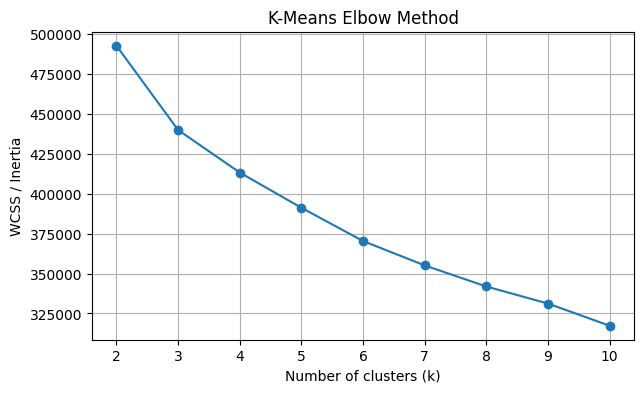

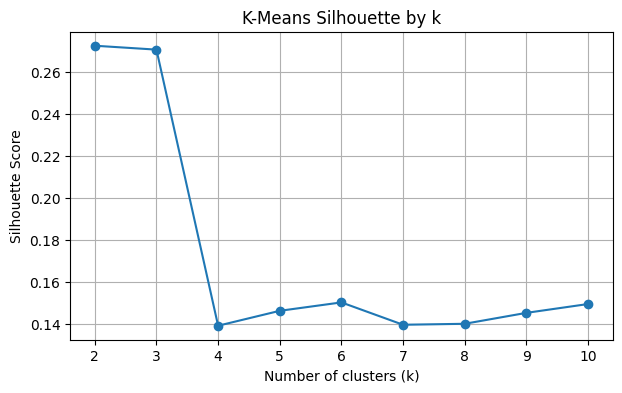

Selected best k: 2


In [7]:
k_range = range(2, 11)
kmeans_eval = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_processed)

    sil = silhouette_score(X_processed, labels, sample_size=5000, random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X_processed, labels)

    kmeans_eval.append({
        "k": k,
        "wcss": model.inertia_,
        "silhouette": sil,
        "dbi": dbi
    })

kmeans_eval_df = pd.DataFrame(kmeans_eval)
display(kmeans_eval_df)

# Plot elbow
plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["wcss"], marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)
plt.show()

# Plot silhouette
plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval_df["k"], kmeans_eval_df["silhouette"], marker="o")
plt.title("K-Means Silhouette by k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Choose k based on highest silhouette score
best_k = int(kmeans_eval_df.sort_values(["silhouette", "dbi"], ascending=[False, True]).iloc[0]["k"])
print("Selected best k:", best_k)


In [8]:
kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_processed)

kmeans_silhouette = silhouette_score(X_processed, kmeans_labels, sample_size=5000, random_state=RANDOM_STATE)
kmeans_dbi = davies_bouldin_score(X_processed, kmeans_labels)

print(f"K-Means selected k: {best_k}")
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-Means Davies-Bouldin Index: {kmeans_dbi:.4f}")


K-Means selected k: 2
K-Means Silhouette Score: 0.2727
K-Means Davies-Bouldin Index: 1.6737


In [9]:
sample_size = min(8000, X_processed.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_processed.shape[0], size=sample_size, replace=False)
X_sample = X_processed[sample_idx]

param_grid = {
    "eps": [3.0, 4.0, 5.0, 6.0, 7.0],
    "min_samples": [5, 10, 20]
}

dbscan_trials = []

for params in ParameterGrid(param_grid):
    model = DBSCAN(eps=params["eps"], min_samples=params["min_samples"], n_jobs=-1)
    labels = model.fit_predict(X_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    # Evaluate only valid clusterings
    if n_clusters >= 2 and noise_ratio < 0.95:
        mask = labels != -1

        if len(set(labels[mask])) >= 2:
            sil = silhouette_score(X_sample[mask], labels[mask])
            dbi = davies_bouldin_score(X_sample[mask], labels[mask])
        else:
            sil = np.nan
            dbi = np.nan
    else:
        sil = np.nan
        dbi = np.nan

    dbscan_trials.append({
        "eps": params["eps"],
        "min_samples": params["min_samples"],
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": sil,
        "dbi": dbi
    })

dbscan_eval_df = pd.DataFrame(dbscan_trials)
display(dbscan_eval_df.sort_values(["silhouette", "dbi"], ascending=[False, True]))

valid_dbscan = dbscan_eval_df.dropna(subset=["silhouette"]).copy()

if len(valid_dbscan) > 0:
    best_dbscan_params = valid_dbscan.sort_values(["silhouette", "dbi"], ascending=[False, True]).iloc[0].to_dict()
else:
    # fallback params if DBSCAN fails to form valid clusters
    best_dbscan_params = {"eps": 5.0, "min_samples": 10}

print("Selected DBSCAN params:", best_dbscan_params)


,eps,min_samples,n_clusters,noise_ratio,silhouette,dbi
2,3.0,20,2,0.075000,0.422886,0.782080
6,5.0,5,2,0.000125,0.422523,1.072957
7,5.0,10,2,0.000125,0.422523,1.072957
8,5.0,20,2,0.000625,0.419018,1.069445
4,4.0,10,2,0.001875,0.418266,1.066951
3,4.0,5,2,0.001375,0.418094,1.068240
5,4.0,20,2,0.004000,0.416903,1.063013
0,3.0,5,3,0.030625,0.394048,1.648020
1,3.0,10,4,0.047750,0.373758,1.324872
9,6.0,5,1,0.000125,NaN,NaN


Selected DBSCAN params: {'eps': 3.0, 'min_samples': 20.0, 'n_clusters': 2.0, 'noise_ratio': 0.075, 'silhouette': 0.42288636294091925, 'dbi': 0.7820799284651904}


In [10]:
dbscan_model = DBSCAN(
    eps=float(best_dbscan_params["eps"]),
    min_samples=int(best_dbscan_params["min_samples"]),
    n_jobs=-1
)

dbscan_labels = dbscan_model.fit_predict(X_processed)

dbscan_n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
dbscan_noise_ratio = np.mean(dbscan_labels == -1)

if dbscan_n_clusters >= 2:
    mask = dbscan_labels != -1
    dbscan_silhouette = silhouette_score(
        X_processed[mask], dbscan_labels[mask],
        sample_size=min(5000, mask.sum()),
        random_state=RANDOM_STATE
    )
    dbscan_dbi = davies_bouldin_score(X_processed[mask], dbscan_labels[mask])
else:
    dbscan_silhouette = np.nan
    dbscan_dbi = np.nan

print(f"DBSCAN clusters: {dbscan_n_clusters}")
print(f"DBSCAN noise ratio: {dbscan_noise_ratio:.4f}")
print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")
print(f"DBSCAN Davies-Bouldin Index: {dbscan_dbi}")


DBSCAN clusters: 2
DBSCAN noise ratio: 0.0165
DBSCAN Silhouette Score: 0.41036698105614994
DBSCAN Davies-Bouldin Index: 1.0380050852885125


In [11]:
comparison_df = pd.DataFrame([
    {
        "model": "K-Means",
        "silhouette": kmeans_silhouette,
        "dbi": kmeans_dbi,
        "n_clusters": best_k,
        "noise_ratio": 0.0,
        "deployable_for_new_input": True
    },
    {
        "model": "DBSCAN",
        "silhouette": dbscan_silhouette,
        "dbi": dbscan_dbi,
        "n_clusters": dbscan_n_clusters,
        "noise_ratio": dbscan_noise_ratio,
        "deployable_for_new_input": False
    }
])

display(comparison_df)

# Metric-based best model
valid_comparison = comparison_df.dropna(subset=["silhouette"]).copy()
metric_best_model = valid_comparison.sort_values(["silhouette", "dbi"], ascending=[False, True]).iloc[0]["model"]

# Final deployable model:
# K-Means is used for app prediction because it supports predict() for new customer input.
final_model_name = "K-Means"

print("Metric-based best model:", metric_best_model)
print("Final deployable model:", final_model_name)


,model,silhouette,dbi,n_clusters,noise_ratio,deployable_for_new_input
0,K-Means,0.272668,1.673727,2,0.000000,True
1,DBSCAN,0.410367,1.038005,2,0.016534,False


Metric-based best model: DBSCAN
Final deployable model: K-Means


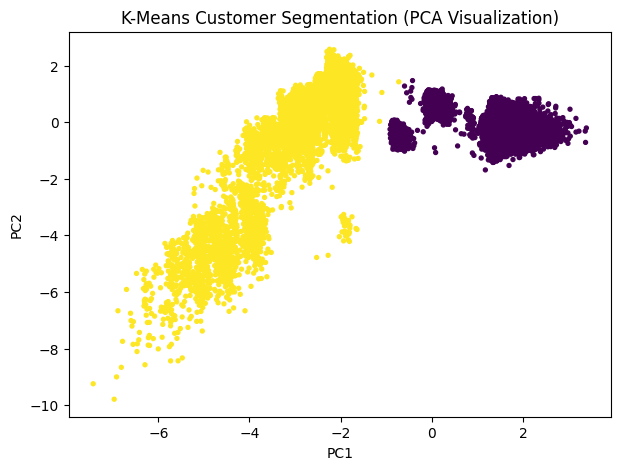

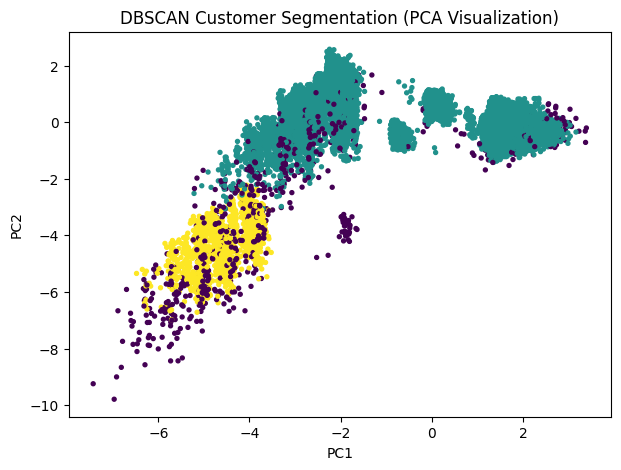

In [12]:
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans_Cluster": kmeans_labels,
    "DBSCAN_Cluster": dbscan_labels
})

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["PC1"], plot_df["PC2"], c=plot_df["KMeans_Cluster"], s=8)
plt.title("K-Means Customer Segmentation (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["PC1"], plot_df["PC2"], c=plot_df["DBSCAN_Cluster"], s=8)
plt.title("DBSCAN Customer Segmentation (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [13]:
df_profile = data.copy()
df_profile["cluster"] = kmeans_labels

numeric_profile_features = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]

numeric_profile_features = [col for col in numeric_profile_features if col in df_profile.columns]

cluster_numeric_profile = df_profile.groupby("cluster")[numeric_profile_features].mean().round(3)
cluster_size = df_profile["cluster"].value_counts().sort_index().rename("customer_count")

# Categorical mode for key features
categorical_profile_features = ["job", "marital", "education", "housing", "loan", "default", "poutcome"]
categorical_profile_features = [col for col in categorical_profile_features if col in df_profile.columns]

cluster_categorical_profile = df_profile.groupby("cluster")[categorical_profile_features].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan)

cluster_profiles = pd.concat([cluster_size, cluster_numeric_profile, cluster_categorical_profile], axis=1)

display(cluster_profiles)


,customer_count,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job,marital,education,housing,loan,default,poutcome
cluster,,,,,,,,,,,,,,,,,,
0,27653,40.194,252.354,2.800,999.000,0.025,1.117,93.844,-39.459,4.818,5213.409,admin.,married,university.degree,yes,no,no,nonexistent
1,13535,39.677,270.402,2.092,887.853,0.475,-2.034,93.028,-42.636,1.176,5072.292,admin.,married,university.degree,yes,no,no,nonexistent


In [14]:
def safe_minmax(value, min_value, max_value):
    if pd.isna(value):
        return 0.0
    if max_value == min_value:
        return 0.0
    return float(np.clip((value - min_value) / (max_value - min_value), 0, 1))

def generate_strategy_scores_from_cluster(cluster_id, df):
    cluster_df = df[df["cluster"] == cluster_id].copy()

    if cluster_df.empty:
        return {}

    # Cluster-level raw values
    avg_campaign = cluster_df["campaign"].mean()
    avg_previous = cluster_df["previous"].mean()
    avg_pdays = cluster_df["pdays"].replace(999, np.nan).mean()
    avg_duration = cluster_df["duration"].mean()
    avg_euribor = cluster_df["euribor3m"].mean()
    avg_emp = cluster_df["emp.var.rate"].mean()
    success_rate = (cluster_df["poutcome"] == "success").mean() if "poutcome" in cluster_df.columns else 0

    if pd.isna(avg_pdays):
        avg_pdays = 999

    # Normalize using dataset ranges / expected ranges
    campaign_norm = safe_minmax(avg_campaign, 1, 10)
    previous_norm = safe_minmax(avg_previous, 0, 5)
    recency_norm = 1 - safe_minmax(min(avg_pdays, 999), 0, 999)  # higher = more recent previous contact
    duration_norm = safe_minmax(avg_duration, 0, 1000)
    euribor_norm = safe_minmax(avg_euribor, 0, 6)
    emp_norm = safe_minmax(avg_emp, -4, 2)

    # Derived intelligence scores
    engagement_score = (
        0.35 * duration_norm +
        0.25 * previous_norm +
        0.25 * recency_norm +
        0.15 * (1 - campaign_norm)
    )

    value_score = (
        0.50 * euribor_norm +
        0.30 * emp_norm +
        0.20 * success_rate
    )

    fatigue_score = (
        0.70 * campaign_norm +
        0.30 * (1 - success_rate)
    )

    # Strategy scoring
    scores = {
        "Awareness Strategy": (1 - engagement_score) * 0.70 + (1 - success_rate) * 0.30,
        "Conversion Strategy": engagement_score * 0.50 + success_rate * 0.30 + (1 - fatigue_score) * 0.20,
        "Retention Strategy": fatigue_score * 0.50 + engagement_score * 0.30 + (1 - success_rate) * 0.20,
        "High-Value Strategy": value_score * 0.60 + engagement_score * 0.40,
    }

    scores = {k: round(float(np.clip(v, 0, 1)), 4) for k, v in scores.items()}
    ranked_scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

    return ranked_scores

strategy_scores = {}

for cluster_id in sorted(df_profile["cluster"].unique()):
    strategy_scores[int(cluster_id)] = generate_strategy_scores_from_cluster(cluster_id, df_profile)

strategy_scores_df = pd.DataFrame(strategy_scores).T
strategy_scores_df.index.name = "cluster"

display(strategy_scores_df)

# Top recommendation per cluster
top_recommendations = strategy_scores_df.idxmax(axis=1).rename("top_recommendation")
display(top_recommendations)


,Awareness Strategy,Retention Strategy,High-Value Strategy,Conversion Strategy
cluster,,,,
0,0.8533,0.4829,0.4783,0.2168
1,0.6205,0.5066,0.3294,0.4089


cluster
0    Awareness Strategy
1    Awareness Strategy
Name: top_recommendation, dtype: str

In [15]:
scoring_data = df_profile[
    [
        "cluster",
        "age", "duration", "campaign", "pdays", "previous",
        "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
        "job", "marital", "education", "housing", "loan", "default", "poutcome"
    ]
].copy()

# Keep only existing columns
scoring_data = scoring_data[[col for col in scoring_data.columns if col in df_profile.columns]]

display(scoring_data.head())


,cluster,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job,marital,education,housing,loan,default,poutcome
0,0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,housemaid,married,basic.4y,no,no,no,nonexistent
1,0,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,services,married,high.school,no,no,unknown,nonexistent
2,0,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,services,married,high.school,yes,no,no,nonexistent
3,0,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,admin.,married,basic.6y,no,no,no,nonexistent
4,0,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,services,married,high.school,no,yes,no,nonexistent


In [ ]:
model_results = {
    "comparison": comparison_df.to_dict(orient="records"),
    "kmeans_evaluation_by_k": kmeans_eval_df.to_dict(orient="records"),
    "dbscan_parameter_trials": dbscan_eval_df.to_dict(orient="records"),
    "metric_best_model": metric_best_model,
    "final_deployable_model": final_model_name,
    "final_k": best_k,
    "dbscan_params": {
        "eps": float(best_dbscan_params["eps"]),
        "min_samples": int(best_dbscan_params["min_samples"])
    },
    "notes": "DBSCAN is used for comparative validation. K-Means is used as deployable model because it supports predict() for new user input."
}

# Save models and processing objects
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(kmeans_model, "kmeans_model.pkl")
joblib.dump(dbscan_model, "dbscan_model.pkl")
joblib.dump(pca_vis, "pca_model.pkl")

# Save arrays / data
joblib.dump(X_processed, "X_processed.pkl")
joblib.dump(kmeans_labels, "clusters.pkl")  # backward compatibility with old app
joblib.dump(scoring_data, "scoring_data.pkl")
joblib.dump(cluster_profiles, "cluster_profiles.pkl")
joblib.dump(strategy_scores_df, "strategy_scores.pkl")
joblib.dump(model_results, "model_results.pkl")
joblib.dump(selected_cols, "selected_features.pkl")
joblib.dump(processed_feature_names, "processed_feature_names.pkl")

print("Artifacts saved successfully:")
print("- preprocessor.pkl")
print("- kmeans_model.pkl")
print("- dbscan_model.pkl")
print("- pca_model.pkl")
print("- X_processed.pkl")
print("- clusters.pkl")
print("- scoring_data.pkl")
print("- cluster_profiles.pkl")
print("- strategy_scores.pkl")
print("- model_results.pkl")
print("- selected_features.pkl")
print("- processed_feature_names.pkl")


Artifacts saved successfully:
- preprocessor.pkl
- kmeans_model.pkl
- dbscan_model.pkl
- pca_model.pkl
- X_processed.pkl
- clusters.pkl
- scoring_data.pkl
- cluster_profiles.pkl
- strategy_scores.pkl
- model_results.pkl
- selected_features.pkl
- processed_feature_names.pkl


In [17]:
print(model_results)

{'comparison': [{'model': 'K-Means', 'silhouette': 0.27266822580331873, 'dbi': 1.6737271172925872, 'n_clusters': 2, 'noise_ratio': 0.0, 'deployable_for_new_input': True}, {'model': 'DBSCAN', 'silhouette': 0.41036698105614994, 'dbi': 1.0380050852885125, 'n_clusters': 2, 'noise_ratio': 0.016533941924832474, 'deployable_for_new_input': False}], 'kmeans_evaluation_by_k': [{'k': 2, 'wcss': 492858.55328752345, 'silhouette': 0.27266822580331873, 'dbi': 1.6737271172925872}, {'k': 3, 'wcss': 440024.5649808448, 'silhouette': 0.2708056416069182, 'dbi': 1.4594040046551464}, {'k': 4, 'wcss': 413345.15407783905, 'silhouette': 0.13934598775564658, 'dbi': 2.1549629963638828}, {'k': 5, 'wcss': 391247.7659389122, 'silhouette': 0.14644725959094904, 'dbi': 2.203617141054706}, {'k': 6, 'wcss': 370392.3851032274, 'silhouette': 0.15044862160587583, 'dbi': 2.0383834181789475}, {'k': 7, 'wcss': 355094.5708594264, 'silhouette': 0.13980550510457296, 'dbi': 2.0132791734084363}, {'k': 8, 'wcss': 341880.66320145753